#### **Player Club-Strength Signal**

Goal: test whether player club-strength metrics are related to World Cup participation and scoring.

This focused EDA motivates the player-informed squad features used later in modeling.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120


def repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / "README.md").exists() and (path / "data").exists():
            return path
    raise FileNotFoundError("Could not find repo root with README.md and data/.")


REPO_ROOT = repo_root()
PLAYER_PATH = REPO_ROOT / "data" / "processed" / "player_stats_with_club_elo.csv"

df = pd.read_csv(PLAYER_PATH)
df_found = df[df["perf_found"].fillna(False)].copy()
df_elo = df_found[df_found["club_strength"].notna()].copy()

print(f"Total players: {len(df)}")
print(f"With club data: {len(df_found)} ({len(df_found) / len(df):.1%})")
print(
    f"With club strength: {len(df_elo)} ({len(df_elo) / len(df_found):.1%} of players with club data)"
)
print(
    f"Club strength range: {df_elo['club_strength'].min():.0f} to {df_elo['club_strength'].max():.0f}"
)
print(f"Median club strength: {df_elo['club_strength'].median():.0f}")

Total players: 2890
With club data: 2664 (92.2%)
With club strength: 2231 (83.7% of players with club data)
Club strength range: 1230 to 2075
Median club strength: 1723


##### **Section 1 - Club Strength Distribution**

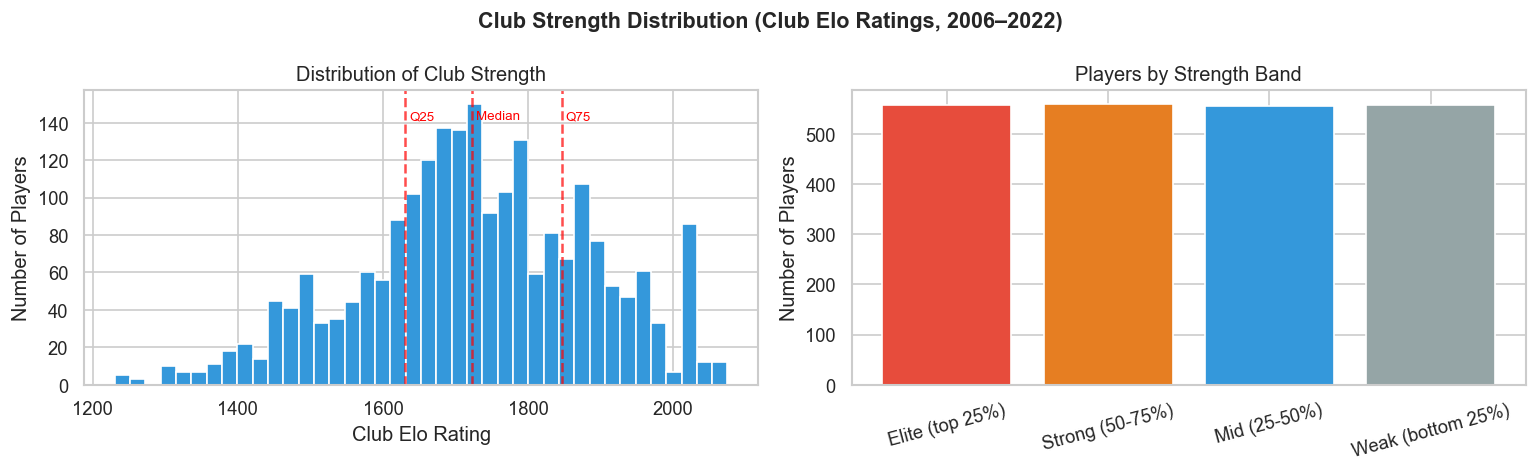


Strength band thresholds:
Elite (top 25%): Elo ≥ 1847
Strong (50-75%): Elo 1723 – 1847
Mid (25-50%): Elo 1631 – 1723
Weak (bottom 25%): Elo < 1631


In [2]:
# Define strength bands based on Elo percentiles
q25, q50, q75 = df_elo["club_strength"].quantile([0.25, 0.50, 0.75])


# Top 25% = Elite (>1847), 50-75% = Strong (1723-1847), 25-50% = Mid (1631-1723), Bottom 25% = Weak (<1631)
def strength_band(elo):
    if elo >= q75:
        return "Elite (top 25%)"
    if elo >= q50:
        return "Strong (50-75%)"
    if elo >= q25:
        return "Mid (25-50%)"
    return "Weak (bottom 25%)"


df_elo["strength_band"] = df_elo["club_strength"].apply(strength_band)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(
    "Club Strength Distribution (Club Elo Ratings, 2006–2022)",
    fontsize=13,
    fontweight="bold",
)

# Histogram
axes[0].hist(df_elo["club_strength"], bins=40, color="#3498db", edgecolor="white")
for q, label in [(q25, "Q25"), (q50, "Median"), (q75, "Q75")]:
    axes[0].axvline(q, color="red", linestyle="--", alpha=0.7)
    axes[0].text(q + 5, axes[0].get_ylim()[1] * 0.9, label, fontsize=8, color="red")
axes[0].set_xlabel("Club Elo Rating")
axes[0].set_ylabel("Number of Players")
axes[0].set_title("Distribution of Club Strength")

# Band breakdown
band_order = ["Elite (top 25%)", "Strong (50-75%)", "Mid (25-50%)", "Weak (bottom 25%)"]
band_counts = df_elo["strength_band"].value_counts().reindex(band_order)
colors = ["#e74c3c", "#e67e22", "#3498db", "#95a5a6"]
axes[1].bar(band_counts.index, band_counts.values, color=colors)
axes[1].set_title("Players by Strength Band")
axes[1].set_ylabel("Number of Players")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

print(f"\nStrength band thresholds:")
print(f"Elite (top 25%): Elo ≥ {q75:.0f}")
print(f"Strong (50-75%): Elo {q50:.0f} – {q75:.0f}")
print(f"Mid (25-50%): Elo {q25:.0f} – {q50:.0f}")
print(f"Weak (bottom 25%): Elo < {q25:.0f}")

##### **Section 2 - World Cup Performance by Club Strength**

WC performance by club strength band:

                   n_players  avg_wc_goals  pct_scored  avg_matches  avg_starts
strength_band                                                                  
Elite (top 25%)          558         0.500       0.297        3.573       3.054
Strong (50-75%)          560         0.298       0.198        2.839       2.189
Mid (25-50%)             555         0.198       0.153        2.512       1.910
Weak (bottom 25%)        558         0.111       0.095        2.097       1.577


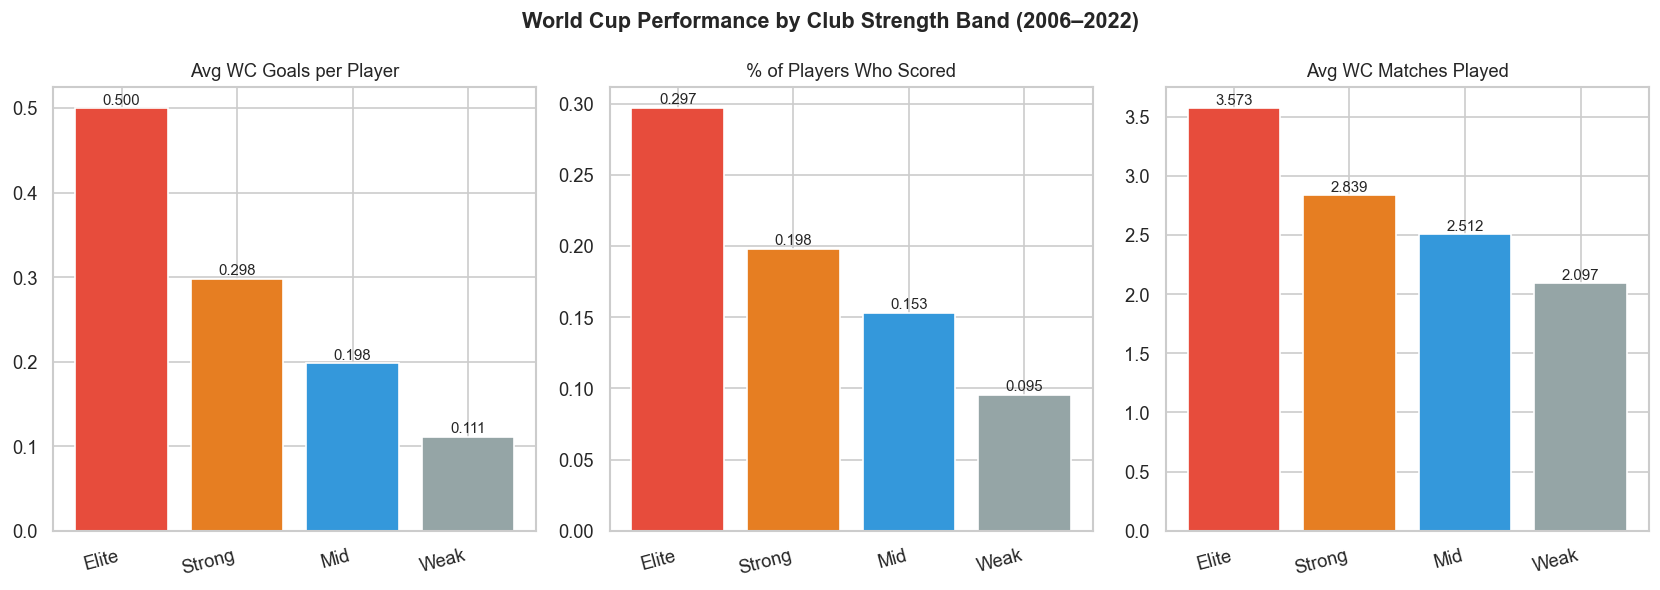

In [3]:
band_order = ["Elite (top 25%)", "Strong (50-75%)", "Mid (25-50%)", "Weak (bottom 25%)"]
colors = ["#e74c3c", "#e67e22", "#3498db", "#95a5a6"]

band_stats = (
    df_elo.groupby("strength_band")
    .agg(
        n_players=("player_id", "count"),
        avg_wc_goals=("wc_goals", "mean"),
        pct_scored=("wc_goals", lambda x: (x > 0).mean()),
        avg_matches=("matches_played", "mean"),
        avg_starts=("starts", "mean"),
    )
    .reindex(band_order)
    .round(3)
)

print("WC performance by club strength band:\n")
print(band_stats.to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(
    "World Cup Performance by Club Strength Band (2006–2022)",
    fontsize=13,
    fontweight="bold",
)

for ax, (col, title) in zip(
    axes,
    [
        ("avg_wc_goals", "Avg WC Goals per Player"),
        ("pct_scored", "% of Players Who Scored"),
        ("avg_matches", "Avg WC Matches Played"),
    ],
):
    vals = band_stats[col]
    bars = ax.bar(range(len(band_order)), vals, color=colors)
    ax.set_xticks(range(len(band_order)))
    ax.set_xticklabels([b.split(" (")[0] for b in band_order], rotation=15, ha="right")
    ax.set_title(title, fontsize=11)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

##### **Section 3 - Club Strength vs Goals**

# Club strength vs WC goals by position (Spearman correlation):

  forward          n= 508   r=0.332   p=0.0000  significant
  midfielder       n= 751   r=0.212   p=0.0000  significant
  defender         n= 732   r=0.083   p=0.0252  significant
  goal keeper      n= 240   r=-0.032   p=0.6195  


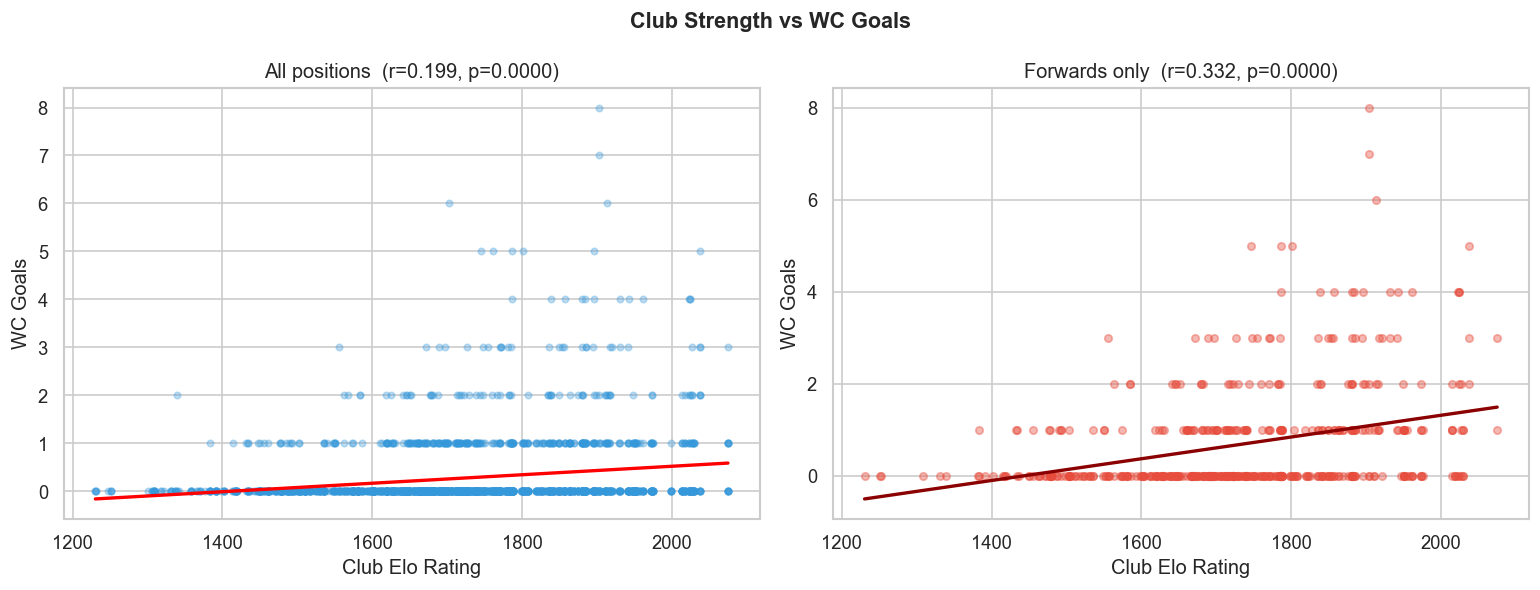

In [4]:
print("# Club strength vs WC goals by position (Spearman correlation):\n")
for pos in ["forward", "midfielder", "defender", "goal keeper"]:
    sub = df_elo[df_elo["position_name"] == pos]
    rho, p = stats.spearmanr(sub["club_strength"], sub["wc_goals"])
    print(
        f"  {pos:<15}  n={len(sub):>4}   r={rho:.3f}   p={p:.4f}  {'significant' if p < 0.05 else ''}"
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Club Strength vs WC Goals", fontsize=13, fontweight="bold")

# All players
axes[0].scatter(
    df_elo["club_strength"], df_elo["wc_goals"], alpha=0.3, s=15, color="#3498db"
)
m, b = np.polyfit(df_elo["club_strength"], df_elo["wc_goals"], 1)
x = np.linspace(df_elo["club_strength"].min(), df_elo["club_strength"].max(), 100)
axes[0].plot(x, m * x + b, color="red", linewidth=2)
rho, p = stats.spearmanr(df_elo["club_strength"], df_elo["wc_goals"])
axes[0].set_xlabel("Club Elo Rating")
axes[0].set_ylabel("WC Goals")
axes[0].set_title(f"All positions  (r={rho:.3f}, p={p:.4f})")

# Forwards only
fwd = df_elo[df_elo["position_name"] == "forward"]
axes[1].scatter(fwd["club_strength"], fwd["wc_goals"], alpha=0.4, s=20, color="#e74c3c")
m2, b2 = np.polyfit(fwd["club_strength"], fwd["wc_goals"], 1)
axes[1].plot(x, m2 * x + b2, color="darkred", linewidth=2)
rho2, p2 = stats.spearmanr(fwd["club_strength"], fwd["wc_goals"])
axes[1].set_xlabel("Club Elo Rating")
axes[1].set_ylabel("WC Goals")
axes[1].set_title(f"Forwards only  (r={rho2:.3f}, p={p2:.4f})")

plt.tight_layout()
plt.show()

##### **Section 4 - Club Form vs World Cup Contribution**

Spearman correlation: club form + strength vs WC performance

   Club metric      WC metric  Spearman r  p-value Sig
 club_strength       wc_goals       0.199   0.0000 yes
minutes_played       wc_goals      -0.097   0.0000 yes
   appearances       wc_goals       0.124   0.0000 yes
    club_goals       wc_goals       0.332   0.0000 yes
       assists       wc_goals       0.272   0.0000 yes
 club_strength matches_played       0.305   0.0000 yes
minutes_played matches_played      -0.060   0.0048 yes
   appearances matches_played       0.163   0.0000 yes
    club_goals matches_played       0.221   0.0000 yes
       assists matches_played       0.259   0.0000 yes
 club_strength         starts       0.288   0.0000 yes
minutes_played         starts       0.002   0.9369    
   appearances         starts       0.142   0.0000 yes
    club_goals         starts       0.069   0.0011 yes
       assists         starts       0.143   0.0000 yes


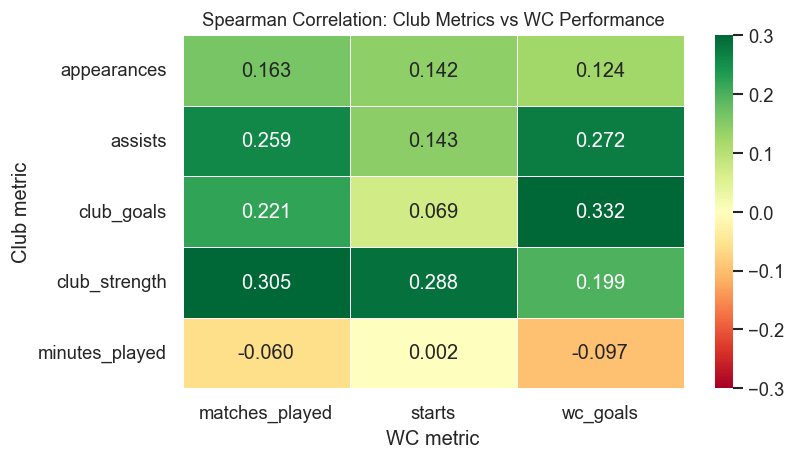

In [5]:
club_form_cols = [
    "club_strength",
    "minutes_played",
    "appearances",
    "club_goals",
    "assists",
]
wc_perf_cols = ["wc_goals", "matches_played", "starts"]

print("Spearman correlation: club form + strength vs WC performance\n")
corr_rows = []
for wc_col in wc_perf_cols:
    for club_col in club_form_cols:
        sub = df_elo[[club_col, wc_col]].dropna()
        rho, p = stats.spearmanr(sub[club_col], sub[wc_col])
        corr_rows.append(
            {
                "Club metric": club_col,
                "WC metric": wc_col,
                "Spearman r": round(rho, 3),
                "p-value": round(p, 4),
                "Sig": "yes" if p < 0.05 else "",
            }
        )

corr_df = pd.DataFrame(corr_rows)
print(corr_df.to_string(index=False))

# Heatmap
pivot = corr_df.pivot(index="Club metric", columns="WC metric", values="Spearman r")
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    ax=ax,
    vmin=-0.3,
    vmax=0.3,
)
ax.set_title("Spearman Correlation: Club Metrics vs WC Performance", fontsize=11)
plt.tight_layout()
plt.show()